In [3]:
import os
import pandas as pd 
import numpy as np
import scanpy as sc
import omicverse as ov

ov.utils.ov_plot_set()

In [4]:
print(os.path.abspath('.'))

/home/munick/PRJCA001063.linux


In [5]:
#ref: https://www.zhihu.com/question/413172418
adata = sc.read_h5ad("zenodo3969339#/StdWf1_PRJCA001063_CRC_besca2.raw.h5ad")
adata

AnnData object with n_obs × n_vars = 57530 × 18008
    obs: 'CELL', 'CONDITION', 'Patient', 'Type', 'Cell_type'
    var: 'ENSEMBL', 'SYMBOL'

In [6]:
adata.var_names_make_unique()
adata.obs_names_make_unique()

In [7]:
adata.var.head(5)
#matrix_to_save=adata.var.head(5000)
#df = pd.DataFrame(matrix_to_save, index=adata.obs_names, columns=adata.var_names)
#df.to_csv('output_matrix.csv', index=True, header=True)

,ENSEMBL,SYMBOL
LINC00115,ENSG00000225880,LINC00115
FAM41C,ENSG00000230368,FAM41C
SAMD11,ENSG00000187634,SAMD11
NOC2L,ENSG00000188976,NOC2L
KLHL17,ENSG00000187961,KLHL17


In [8]:
# 线粒体基因
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# 核糖体基因
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# 血红蛋白基因
adata.var["hb"] = adata.var_names.str.contains(("^HB[^(P)]"))

In [9]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[10], log1p=True
)
adata

AnnData object with n_obs × n_vars = 57530 × 18008
    obs: 'CELL', 'CONDITION', 'Patient', 'Type', 'Cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'ENSEMBL', 'SYMBOL', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [10]:
from scipy.sparse import issparse
if issparse(adata.X):
    adata.obs['nUMIs'] = adata.X.toarray().sum(axis=1)  
    adata.obs['mito_perc'] = adata[:, adata.var["mt"]].X.toarray().sum(axis=1) / adata.obs['nUMIs'].values
    adata.obs['detected_genes'] = (adata.X.toarray() > 0).sum(axis=1)  
else:
    adata.obs['nUMIs'] = adata.X.sum(axis=1)  
    adata.obs['mito_perc'] = adata[:, adata.var["mt"]].X.sum(axis=1) / adata.obs['nUMIs'].values
    adata.obs['detected_genes'] = (adata.X > 0).sum(axis=1)  

adata

AnnData object with n_obs × n_vars = 57530 × 18008
    obs: 'CELL', 'CONDITION', 'Patient', 'Type', 'Cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'nUMIs', 'mito_perc', 'detected_genes'
    var: 'ENSEMBL', 'SYMBOL', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

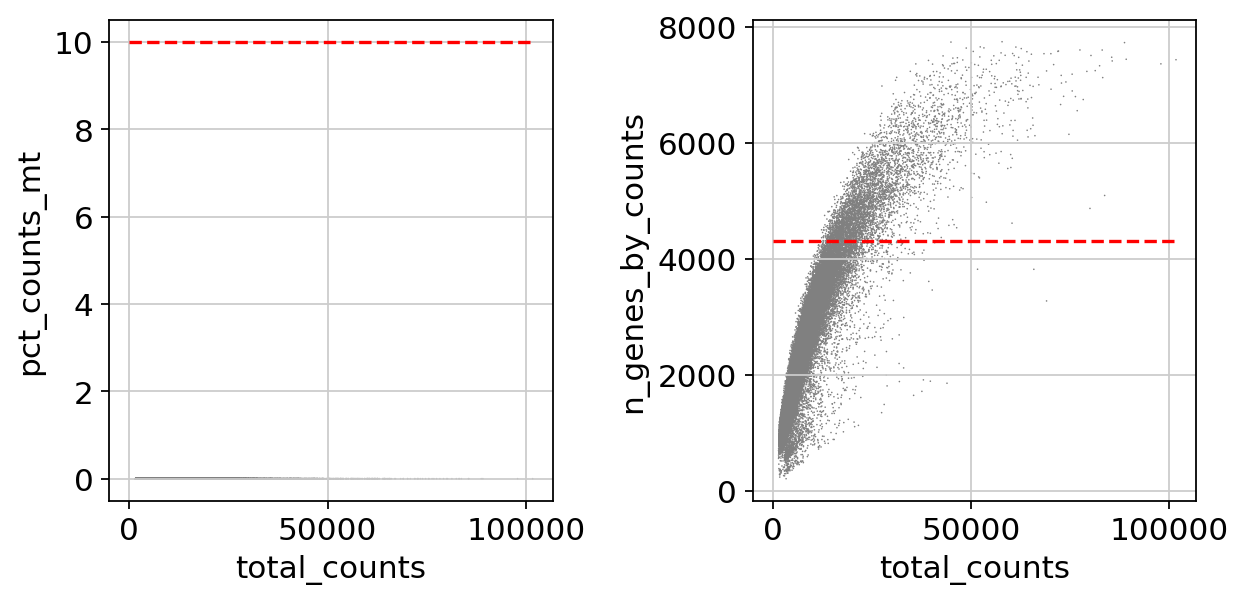

In [11]:
import matplotlib.pyplot as plt
mito_filter = 10
n_counts_filter = 4300
fig, axs = plt.subplots(ncols = 2, figsize = (8,4))
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt',ax = axs[0], show=False)
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts',ax = axs[1], show = False)
#draw horizontal red lines indicating thresholds.
axs[0].hlines(y = mito_filter, xmin = 0, xmax = max(adata.obs['total_counts']), color = 'red', ls = 'dashed')
axs[1].hlines(y = n_counts_filter, xmin = 0, xmax = max(adata.obs['total_counts']), color = 'red', ls = 'dashed')
fig.tight_layout()
plt.show()
#该raw文件似乎已经去除了mito基因

In [12]:
adata.write('01.qualified raw0.h5ad')

In [13]:
import os
import pandas as pd 
import numpy as np
import scanpy as sc
import omicverse as ov

ov.utils.ov_plot_set()

In [14]:
adata = sc.read_h5ad("01.qualified raw0.h5ad")
adata

AnnData object with n_obs × n_vars = 57530 × 18008
    obs: 'CELL', 'CONDITION', 'Patient', 'Type', 'Cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'nUMIs', 'mito_perc', 'detected_genes'
    var: 'ENSEMBL', 'SYMBOL', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [ ]:
adata=ov.pp.qc(adata,
              tresh={'mito_perc': 0.1, 'nUMIs': 500, 'detected_genes': 250})
adata

Calculate QC metrics
End calculation of QC metrics.
Original cell number: 57530
Begin of post doublets removal and QC plot
Running Scrublet
filtered out 176 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:07)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)


In [12]:
adata.write('01.qualified raw.h5ad')

In [1]:
import os
import pandas as pd 
import numpy as np
import scanpy as sc
import omicverse as ov

ov.utils.ov_plot_set()


   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.5.8, Tutorials: https://omicverse.readthedocs.io/


In [2]:
adata = sc.read_h5ad("01.qualified raw.h5ad")
adata

AnnData object with n_obs × n_vars = 57530 × 18008
    obs: 'CELL', 'CONDITION', 'Patient', 'Type', 'Cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'nUMIs', 'mito_perc', 'detected_genes'
    var: 'ENSEMBL', 'SYMBOL', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [3]:
ov.utils.store_layers(adata,layers='counts')
adata

......The X of adata have been stored in counts


AnnData object with n_obs × n_vars = 57530 × 18008
    obs: 'CELL', 'CONDITION', 'Patient', 'Type', 'Cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'nUMIs', 'mito_perc', 'detected_genes'
    var: 'ENSEMBL', 'SYMBOL', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'layers_counts'

In [4]:
adata=ov.pp.preprocess(adata,mode='shiftlog|pearson',n_HVGs=2000,)
adata

Begin robust gene identification
After filtration, 17982/18008 genes are kept. Among 17982 genes, 16797 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['S100A6', 'REG3A', 'SST', 'APOD', 'JCHAIN', 'SPP1', 'SCGB3A1', 'PRSS1', 'TIMP1', 'INS', 'HBB', 'FTH1', 'MALAT1', 'HBA2', 'PPY', 'FTL', 'IGLL5', 'CTRB2']
    finished (0:00:00)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)
End of size normalization: shiftlog and HVGs selection pearson


AnnData object with n_obs × n_vars = 57530 × 16797
    obs: 'CELL', 'CONDITION', 'Patient', 'Type', 'Cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'nUMIs', 'mito_perc', 'detected_genes'
    var: 'ENSEMBL', 'SYMBOL', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'percent_cells', 'robust', 'mean', 'var', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'layers_counts', 'log1p', 'hvg'
    layers: 'counts'

In [5]:
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]
adata

View of AnnData object with n_obs × n_vars = 57530 × 2000
    obs: 'CELL', 'CONDITION', 'Patient', 'Type', 'Cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'nUMIs', 'mito_perc', 'detected_genes'
    var: 'ENSEMBL', 'SYMBOL', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'percent_cells', 'robust', 'mean', 'var', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'layers_counts', 'log1p', 'hvg'
    layers: 'counts'

In [6]:
adata_counts=adata.copy()
ov.utils.retrieve_layers(adata_counts,layers='counts')
print('normalize adata:',adata.X.max())
print('raw count adata:',adata_counts.X.max())

......The X of adata have been stored in raw
......The layers counts of adata have been retreved
normalize adata: 14.309932
raw count adata: 38145.0


In [7]:
adata_counts
adata.write('01.qualified raw-2.h5ad')

In [8]:
adata = sc.read_h5ad("01.qualified raw-2.h5ad")
adata

AnnData object with n_obs × n_vars = 57530 × 2000
    obs: 'CELL', 'CONDITION', 'Patient', 'Type', 'Cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'nUMIs', 'mito_perc', 'detected_genes'
    var: 'ENSEMBL', 'SYMBOL', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'percent_cells', 'robust', 'mean', 'var', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'hvg', 'layers_counts', 'log1p'
    layers: 'counts'

In [9]:
ov.pp.scale(adata)
adata

... as `zero_center=True`, sparse input is densified and may lead to large memory consumption


AnnData object with n_obs × n_vars = 57530 × 2000
    obs: 'CELL', 'CONDITION', 'Patient', 'Type', 'Cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'nUMIs', 'mito_perc', 'detected_genes'
    var: 'ENSEMBL', 'SYMBOL', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'percent_cells', 'robust', 'mean', 'var', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'hvg', 'layers_counts', 'log1p'
    layers: 'counts', 'scaled'

In [10]:
ov.pp.pca(adata,layer='scaled',n_pcs=50)
adata

AnnData object with n_obs × n_vars = 57530 × 2000
    obs: 'CELL', 'CONDITION', 'Patient', 'Type', 'Cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'nUMIs', 'mito_perc', 'detected_genes'
    var: 'ENSEMBL', 'SYMBOL', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'percent_cells', 'robust', 'mean', 'var', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'hvg', 'layers_counts', 'log1p', 'scaled|original|pca_var_ratios', 'scaled|original|cum_sum_eigenvalues'
    obsm: 'scaled|original|X_pca'
    varm: 'scaled|original|pca_loadings'
    layers: 'counts', 'scaled', 'lognorm'

In [12]:
adata.write('01.qualified raw-3.h5ad')

In [13]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50,
               use_rep='scaled|original|X_pca')

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:58)


In [14]:
#pip install pymde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 165.5 kB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [14]:
adata.obsm["X_mde"] = ov.utils.mde(adata.obsm["scaled|original|X_pca"])
adata

AnnData object with n_obs × n_vars = 57530 × 2000
    obs: 'CELL', 'CONDITION', 'Patient', 'Type', 'Cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'nUMIs', 'mito_perc', 'detected_genes'
    var: 'ENSEMBL', 'SYMBOL', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'percent_cells', 'robust', 'mean', 'var', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'hvg', 'layers_counts', 'log1p', 'scaled|original|pca_var_ratios', 'scaled|original|cum_sum_eigenvalues', 'neighbors'
    obsm: 'scaled|original|X_pca', 'X_pca', 'X_mde'
    varm: 'scaled|original|pca_loadings'
    layers: 'counts', 'scale

In [16]:
sc.tl.umap(adata)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:01:03)


In [18]:
sc.tl.leiden(adata)

running Leiden clustering
    finished: found 41 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:01:07)


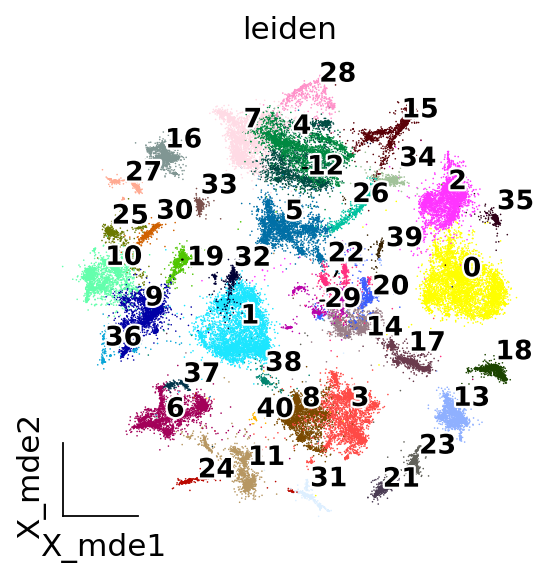

In [20]:
from matplotlib import patheffects
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4,4))

ov.utils.embedding(adata,
                  basis='X_mde',
                  color=['leiden'],
                   show=False, legend_loc=None, add_outline=False, 
                   frameon='small',legend_fontoutline=2,ax=ax
                 )

ov.utils.gen_mpl_labels(
    adata,
    'leiden',
    exclude=("None",),  
    basis='X_mde',
    ax=ax,
    adjust_kwargs=dict(arrowprops=dict(arrowstyle='-', color='black')),
    text_kwargs=dict(fontsize= 12 ,weight='bold',
                     path_effects=[patheffects.withStroke(linewidth=2, foreground='w')] ),
)

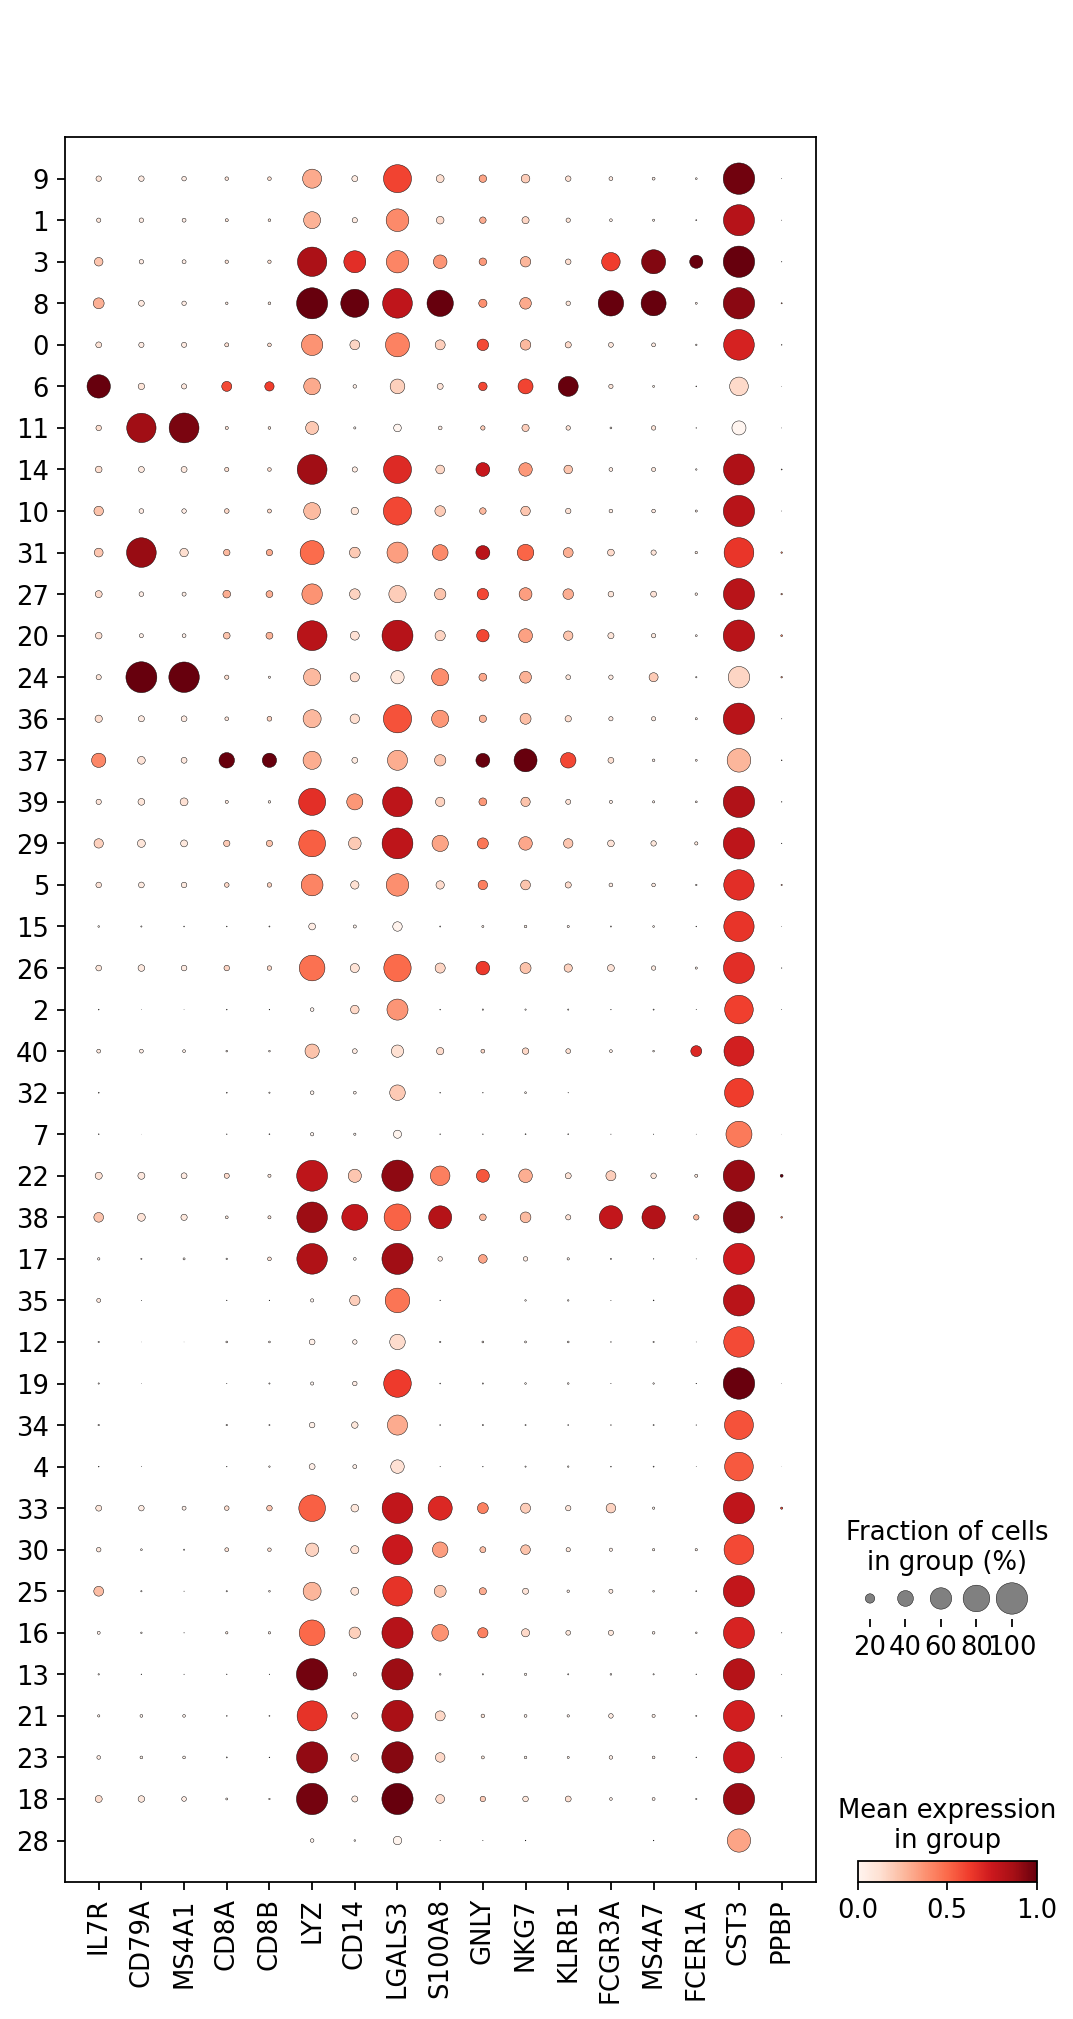

In [21]:
marker_genes = ['IL7R', 'CD79A', 'MS4A1', 'CD8A', 'CD8B', 'LYZ', 'CD14',
                'LGALS3', 'S100A8', 'GNLY', 'NKG7', 'KLRB1',
                'FCGR3A', 'MS4A7', 'FCER1A', 'CST3', 'PPBP']
sc.pl.dotplot(adata, marker_genes, groupby='leiden',
             standard_scale='var');

In [22]:
adata

AnnData object with n_obs × n_vars = 57530 × 2000
    obs: 'CELL', 'CONDITION', 'Patient', 'Type', 'Cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'nUMIs', 'mito_perc', 'detected_genes', 'leiden'
    var: 'ENSEMBL', 'SYMBOL', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'percent_cells', 'robust', 'mean', 'var', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'hvg', 'layers_counts', 'log1p', 'scaled|original|pca_var_ratios', 'scaled|original|cum_sum_eigenvalues', 'neighbors', 'umap', 'leiden', 'leiden_colors'
    obsm: 'scaled|original|X_pca', 'X_pca', 'X_mde', 'X_umap'
    varm: 'sca

In [23]:
adata_counts
adata.write('01.qualified raw-4.h5ad')

In [1]:
import os
import pandas as pd 
import numpy as np
import scanpy as sc
import omicverse as ov

ov.utils.ov_plot_set()

adata = sc.read_h5ad("01.qualified raw-4.h5ad")
adata


   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.5.8, Tutorials: https://omicverse.readthedocs.io/


AnnData object with n_obs × n_vars = 57530 × 2000
    obs: 'CELL', 'CONDITION', 'Patient', 'Type', 'Cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'nUMIs', 'mito_perc', 'detected_genes', 'leiden'
    var: 'ENSEMBL', 'SYMBOL', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'percent_cells', 'robust', 'mean', 'var', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'hvg', 'layers_counts', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'scaled|original|cum_sum_eigenvalues', 'scaled|original|pca_var_ratios', 'umap'
    obsm: 'X_mde', 'X_pca', 'X_umap', 'scaled|original|X_pca'
    varm: 'sca

In [3]:
adata.obs['Patient'].unique()

['T1', 'T2', 'T3', 'T4', 'T5', ..., 'N7', 'N8', 'N9', 'N10', 'N11']
Length: 35
Categories (35, object): ['N1', 'N2', 'N3', 'N4', ..., 'T21', 'T22', 'T23', 'T24']

In [4]:
import numpy as np
adata.X=adata.X.astype(np.int64)

In [6]:
#pip install pymde

  Using cached pymde-0.1.18-cp39-cp39-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.4 kB)
Using cached pymde-0.1.18-cp39-cp39-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl (137 kB)
Note: you may need to restart the kernel to use updated packages.


In [6]:
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

adata.obsm["X_mde_pca"] = ov.utils.mde(adata.obsm["scaled|original|X_pca"])

... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
... as scaling leads to float results, integer input is cast to float, returning copy.


[<AxesSubplot: title={'center': 'Patient'}, xlabel='X_mde_pca1', ylabel='X_mde_pca2'>,
 <AxesSubplot: title={'center': 'Cell_type'}, xlabel='X_mde_pca1', ylabel='X_mde_pca2'>]

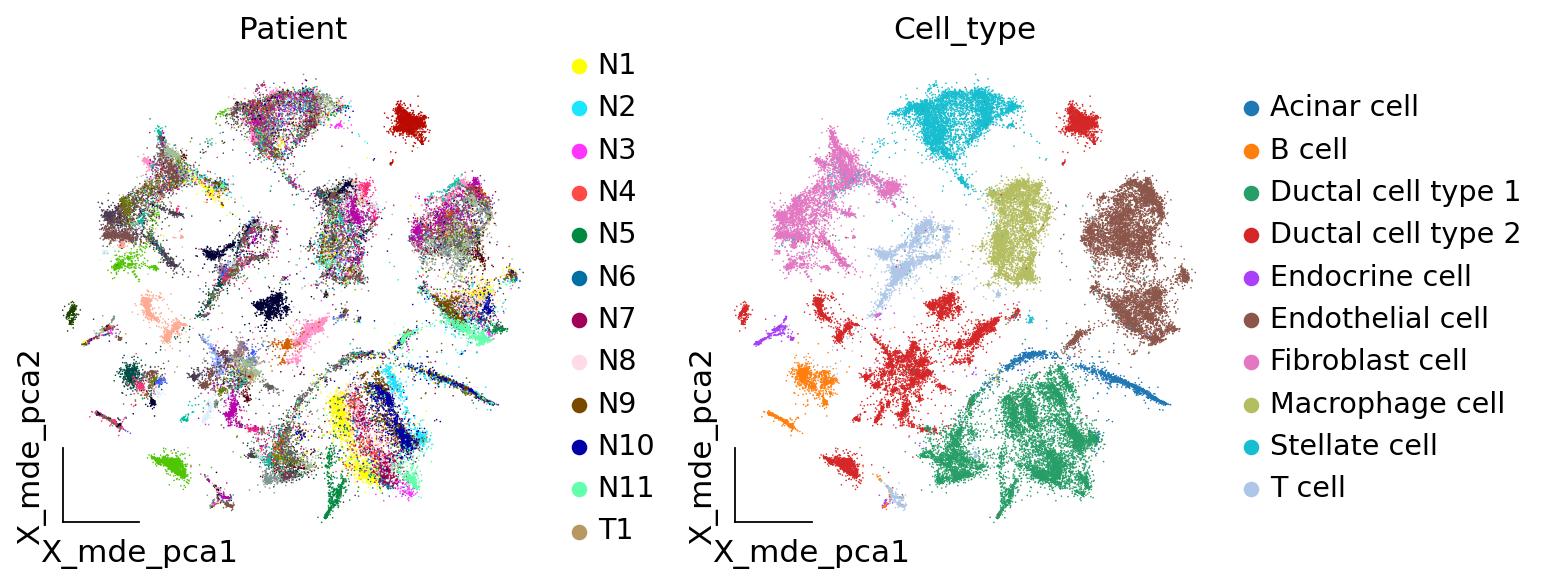

In [7]:
ov.utils.embedding(adata,
                basis='X_mde_pca',frameon='small',
                color=['Patient','Cell_type'],show=False)

In [8]:
adata_harmony=ov.single.batch_correction(adata,batch_key='Patient',
                                        methods='harmony',n_pcs=50)
adata

...Begin using harmony to correct batch effect
... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
... as scaling leads to float results, integer input is cast to float, returning copy.


2024-04-04 21:41:35,228 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f4df7fa8dc0>
Traceback (most recent call last):
  File "/home/munick/anaconda3/envs/omicverse39/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/munick/anaconda3/envs/omicverse39/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/munick/anaconda3/envs/omicverse39/lib/python3.9/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/munick/anaconda3/envs/omicverse39/lib/python3.9/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneTy

AnnData object with n_obs × n_vars = 57530 × 2000
    obs: 'CELL', 'CONDITION', 'Patient', 'Type', 'Cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'nUMIs', 'mito_perc', 'detected_genes', 'leiden'
    var: 'ENSEMBL', 'SYMBOL', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'percent_cells', 'robust', 'mean', 'var', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'hvg', 'layers_counts', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'scaled|original|cum_sum_eigenvalues', 'scaled|original|pca_var_ratios', 'umap', 'Patient_colors', 'Cell_type_colors'
    obsm: 'X_mde', 'X_pca', 'X_umap', 

In [9]:
adata.obsm["X_mde_harmony"] = ov.utils.mde(adata.obsm["X_harmony"])

[<AxesSubplot: title={'center': 'Patient'}, xlabel='X_mde_harmony1', ylabel='X_mde_harmony2'>,
 <AxesSubplot: title={'center': 'Cell_type'}, xlabel='X_mde_harmony1', ylabel='X_mde_harmony2'>]

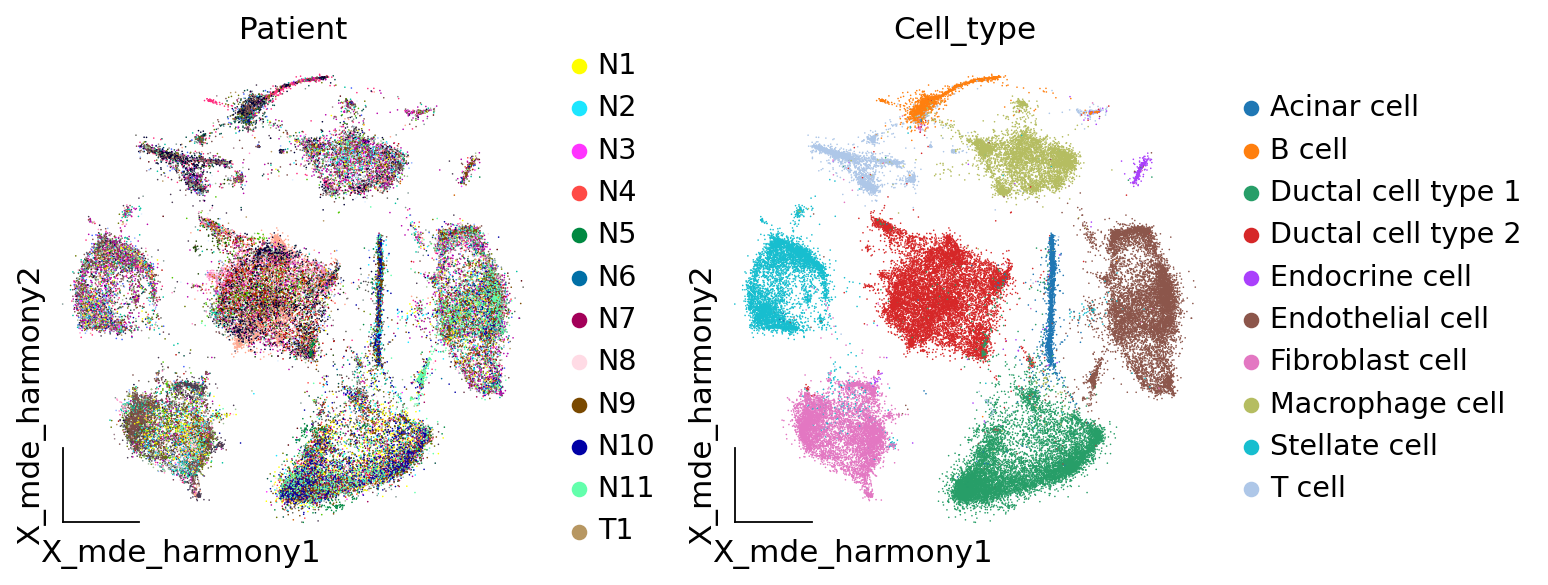

In [10]:
ov.utils.embedding(adata,
                basis='X_mde_harmony',frameon='small',
                color=['Patient','Cell_type'],show=False)

In [12]:
adata.write('01.qualified raw-5.h5ad')